# VA DEQ dataset EDA & Regression Analysis

The purpose of this notebook is to explore the VA DEQ dataset that was joined from two original VA DEQ datasets. The dataset contains helpful parameters such as slope and bankfull width/depth, etc.

E. Reilly Oare

In [1]:
# Read in libs
import os
import pandas as pd
import numpy as np
import pylab
import math
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import curve_fit
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm

In [2]:
# For plotting purposes
mpl.rcParams['font.family'] = 'Arial'

## Step 1. Import dataset

In [3]:
# Define base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

In [4]:
# Read in excel file
tmdl_emd_path = os.path.join(BASE_DIR, "data", "processed", "virginia", "uncleaned_vadeq_emd_joined.xlsx")
tmdl_emd = pd.read_excel(tmdl_emd_path, header = 0).drop(columns = ['Unnamed: 0'])

# Display dataframe
tmdl_emd

,StationID,Date,ReachLength,Slope_x,RP100,BR_PCT,HP_PCT,RC_PCT,BL_PCT,CB_PCT,...,POPCHG2010_2020,POPCHG2000_2020,RDLEN,RDLEN120,STXRD_CNT,RDDENS,pctRoadLengthInRiparian,STXRD,LATITUDE,LONGITUDE
0,1AACO006.10,2006-11-21,440,0.220,34.752500,7.692308,6.730769,0.000000,9.615385,14.423077,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.728611,-77.203333
1,1AACO004.84,2008-06-25,320,0.521,25.757012,0.000000,0.952381,0.000000,5.714286,27.619048,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.720500,-77.190722
2,1AACO006.10,2008-06-26,520,0.173,35.429907,2.857143,7.619048,0.952381,4.761905,21.904762,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.728611,-77.203333
3,1AACO009.14,2008-06-26,560,0.223,22.451871,2.857143,4.761905,0.000000,9.523810,18.095238,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.761944,-77.207222
4,1AAUA017.60,2005-09-22,160,0.400,19.910507,0.000000,0.000000,0.000000,7.619048,34.285714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.490361,-77.466389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,2BXRK001.64,2022-10-26,150,1.287,9.486085,0.952381,5.714286,0.952381,0.000000,13.333333,...,-3.340934,-19.035539,5757.591719,1574.982250,2.0,2.716352,27.354879,0.894433,37.811383,-78.729900
1121,2-JKS070.06,2022-09-12,800,0.450,25.065800,9.523810,0.000000,0.000000,5.714286,30.476190,...,-8.892221,-3.953434,451582.048000,86994.700400,69.0,4.955175,19.264428,0.960441,38.123444,-79.779725
1122,4ASNA007.82,2022-09-20,320,0.430,15.910317,0.000000,0.000000,0.000000,0.000000,0.000000,...,-6.086899,-1.849916,617340.395400,53983.910780,90.0,1.004842,8.744594,0.451753,36.792139,-79.112444
1123,8-MIC001.47,2022-10-25,150,0.300,10.014865,0.000000,9.708738,0.000000,0.000000,0.000000,...,5.915693,-2.301971,58550.497110,7208.478259,12.0,1.883880,12.311558,0.815454,37.753450,-77.720931


## Step 2. Check for null values and drop columns

In [5]:
# Present number of null values for each column
tmdl_emd.isnull().sum()

StationID                    0
Date                         0
ReachLength                  0
Slope_x                      0
RP100                        0
                          ... 
RDDENS                     968
pctRoadLengthInRiparian    968
STXRD                      968
LATITUDE                     8
LONGITUDE                    8
Length: 215, dtype: int64

In [6]:
# Trim the columns with nulls
tmdl_emd.drop(columns=['BL_CB_GR_transectPCT_x',
                      'BL_CB_GRmeanEmbed'],
             inplace = True)

In [7]:
# Display trimmed df
tmdl_emd

,StationID,Date,ReachLength,Slope_x,RP100,BR_PCT,HP_PCT,RC_PCT,BL_PCT,CB_PCT,...,POPCHG2010_2020,POPCHG2000_2020,RDLEN,RDLEN120,STXRD_CNT,RDDENS,pctRoadLengthInRiparian,STXRD,LATITUDE,LONGITUDE
0,1AACO006.10,2006-11-21,440,0.220,34.752500,7.692308,6.730769,0.000000,9.615385,14.423077,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.728611,-77.203333
1,1AACO004.84,2008-06-25,320,0.521,25.757012,0.000000,0.952381,0.000000,5.714286,27.619048,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.720500,-77.190722
2,1AACO006.10,2008-06-26,520,0.173,35.429907,2.857143,7.619048,0.952381,4.761905,21.904762,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.728611,-77.203333
3,1AACO009.14,2008-06-26,560,0.223,22.451871,2.857143,4.761905,0.000000,9.523810,18.095238,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.761944,-77.207222
4,1AAUA017.60,2005-09-22,160,0.400,19.910507,0.000000,0.000000,0.000000,7.619048,34.285714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.490361,-77.466389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,2BXRK001.64,2022-10-26,150,1.287,9.486085,0.952381,5.714286,0.952381,0.000000,13.333333,...,-3.340934,-19.035539,5757.591719,1574.982250,2.0,2.716352,27.354879,0.894433,37.811383,-78.729900
1121,2-JKS070.06,2022-09-12,800,0.450,25.065800,9.523810,0.000000,0.000000,5.714286,30.476190,...,-8.892221,-3.953434,451582.048000,86994.700400,69.0,4.955175,19.264428,0.960441,38.123444,-79.779725
1122,4ASNA007.82,2022-09-20,320,0.430,15.910317,0.000000,0.000000,0.000000,0.000000,0.000000,...,-6.086899,-1.849916,617340.395400,53983.910780,90.0,1.004842,8.744594,0.451753,36.792139,-79.112444
1123,8-MIC001.47,2022-10-25,150,0.300,10.014865,0.000000,9.708738,0.000000,0.000000,0.000000,...,5.915693,-2.301971,58550.497110,7208.478259,12.0,1.883880,12.311558,0.815454,37.753450,-77.720931


## Step 3. Calculate Bankfull Shear Velocity

Since this dataset has some bankfull channel dimensions, we will calculate bankfull shear velocity. Bankfull shear velocity is assumed to directly correlate to embeddedness. Using steady, uniform flow and the wide-channel assumption, we can calcualte $u_*$ using:
$$u_* = \sqrt{g H S}$$
Where:
<br>$g$ is gravity,
<br>$H$ is bankfull channel depth, and
<br>$S$ is slope (dimensionless).

In [8]:
# Calculate dimensionless slope column
tmdl_emd['Slope [m/m]'] = tmdl_emd['Slope_x'] / 100

# Calculate u_star"
tmdl_emd['u* [m/s]'] = np.sqrt(9.81 * tmdl_emd['BKF_depth_in_meters'] * tmdl_emd['Slope [m/m]'])

## Step 4. Establish hypothesized regression

### Logarithmic Regression

In [9]:
# Filter the data
filtered_data = tmdl_emd[tmdl_emd['u* [m/s]'] >= 0.1]
filtered_data = filtered_data[filtered_data['Xembed'] != 0]

# Log-transform u*
filtered_data['log_u*'] = np.log(filtered_data['u* [m/s]'])

# Perform linear regression on log-transformed data
X = sm.add_constant(filtered_data['log_u*'])  # Add a constant term
model = sm.OLS(filtered_data['Xembed'], X).fit()  # Fit OLS

# Get the R-squared value
r_squared = model.rsquared
print(f"R-squared: {r_squared}")

# Get the p-value for the model coefficients
p_value = model.f_pvalue
print(f"P-value: {p_value}")

# Get the residuals
residuals = model.resid

# Print the summary of the model
print(model.summary())

# Predict Xembed using the model on the original x_data
y_pred = model.predict(X)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(filtered_data['Xembed'], y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Calculate MAE
mae = mean_absolute_error(filtered_data['Xembed'], y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

R-squared: 0.3251091604739771
P-value: 1.0868659040218249e-89
                            OLS Regression Results                            
Dep. Variable:                 Xembed   R-squared:                       0.325
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     494.2
Date:                Sun, 08 Jun 2025   Prob (F-statistic):           1.09e-89
Time:                        20:28:27   Log-Likelihood:                -4440.7
No. Observations:                1028   AIC:                             8885.
Df Residuals:                    1026   BIC:                             8895.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

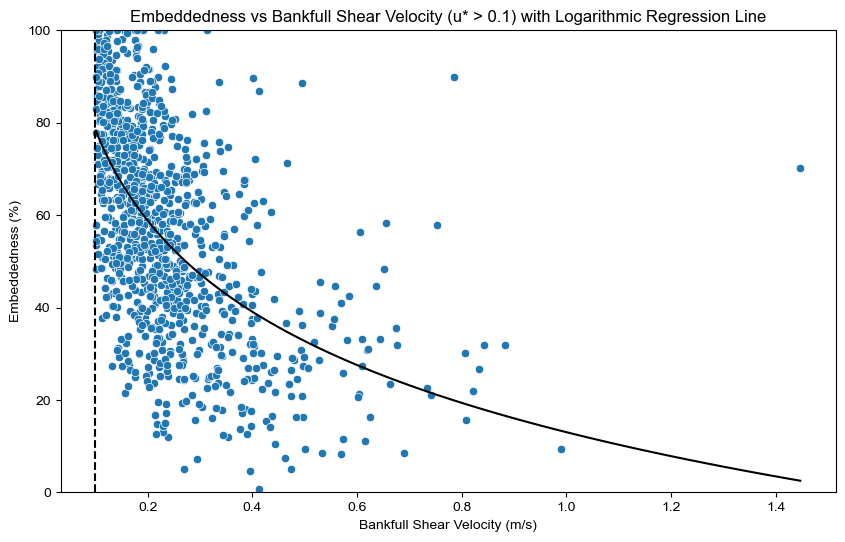

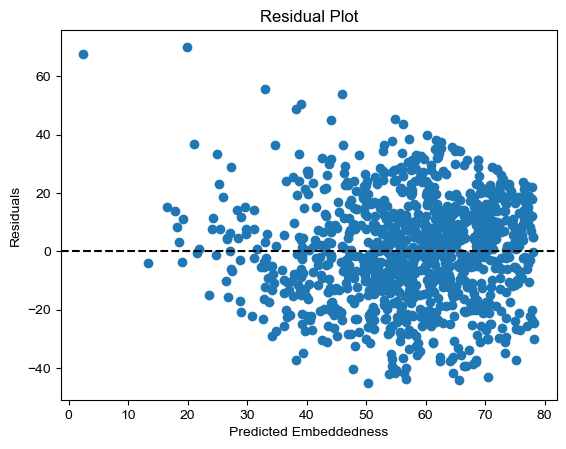

In [10]:
# Prepare data for plotting the regression line

# Create a range of values for u*
u_star_values = np.linspace(filtered_data['u* [m/s]'].min(), filtered_data['u* [m/s]'].max(), 100)
log_u_star_values = np.log(u_star_values)

# Predict 'Xembed' using the model
predicted_Xembed = model.predict(sm.add_constant(log_u_star_values))

# Plot the original data with the regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x='u* [m/s]', y='Xembed', data=filtered_data)
plt.plot(u_star_values, predicted_Xembed, color="k")
plt.ylim(0, 100)
plt.xlabel('Bankfull Shear Velocity (m/s)')
plt.ylabel('Embeddedness (%)')
plt.title('Embeddedness vs Bankfull Shear Velocity (u* > 0.1) with Logarithmic Regression Line')
plt.axvline(x=0.1, color='k', linestyle='--')
plt.show()

# Plot residuals
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted Embeddedness')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='k', linestyle='--')
plt.show()

### Power-Law Regression

Optimal alpha: -0.5395839601053897
Optimal beta: 24.092559851932656
R-squared: 0.32389787475613785
Root Mean Squared Error (RMSE): 18.684817137310127
Mean Absolute Error (MAE): 14.905968704106943


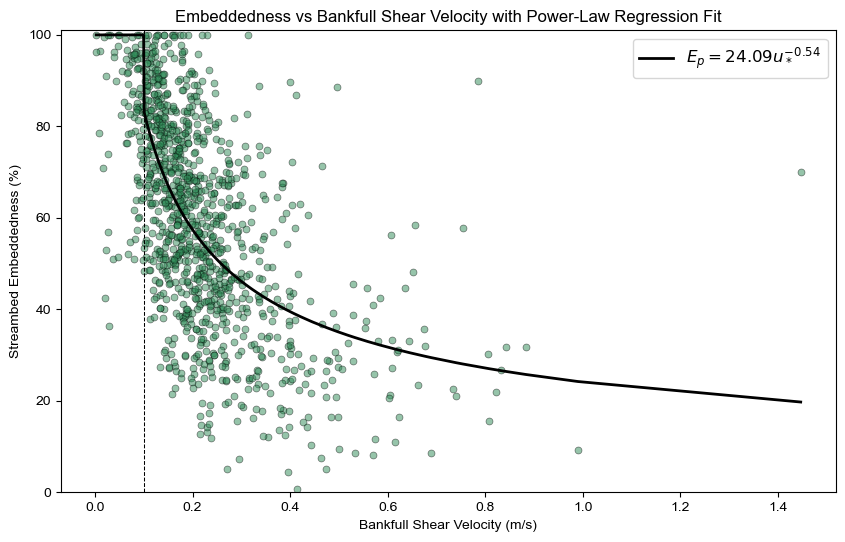

In [11]:
# Define the power-law function
def power_law(x, alpha, beta):
    return beta * np.power(x, alpha)

# Filter the data
filtered_data = tmdl_emd[tmdl_emd['u* [m/s]'] > 0.1]
filtered_data = filtered_data[filtered_data['Xembed'] != 0]

# Extract x and y data
x_data = filtered_data['u* [m/s]']
y_data = filtered_data['Xembed']

# Fit the power-law model
popt, pcov = curve_fit(power_law, x_data, y_data)

# Extract the optimal parameters
alpha_opt, beta_opt = popt
print(f"Optimal alpha: {alpha_opt}")
print(f"Optimal beta: {beta_opt}")

# Apply conditional prediction: use model where u* >= 0.1, otherwise assign 100
predicted_Xembed_all = np.where(
    tmdl_emd['u* [m/s]'] >= 0.1,
    power_law(tmdl_emd['u* [m/s]'], alpha_opt, beta_opt),
    100
)

# Calculate R-squared
residuals = tmdl_emd['Xembed'] - predicted_Xembed_all
ss_res = np.sum(residuals**2)
ss_tot = np.sum((tmdl_emd['Xembed'] - np.mean(tmdl_emd['Xembed']))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R-squared: {r_squared}")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(tmdl_emd['Xembed'], predicted_Xembed_all))
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Calculate MAE
mae = mean_absolute_error(tmdl_emd['Xembed'], predicted_Xembed_all)
print(f"Mean Absolute Error (MAE): {mae}")

# Sort values for cleaner plotting
sorted_indices = tmdl_emd['u* [m/s]'].argsort()
sorted_u = tmdl_emd['u* [m/s]'].values[sorted_indices]
sorted_pred = predicted_Xembed_all[sorted_indices]
beta_round = round(beta_opt, 2)
alpha_round = round(alpha_opt, 2)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='u* [m/s]', y='Xembed', data=tmdl_emd, edgecolor = 'k', linewidth = 0.5, color = 'seagreen', alpha = 0.5, s = 25)
plt.plot(sorted_u, sorted_pred, color="black", label=rf'$E_p = {beta_round} u_*^{{{alpha_round}}}$', linewidth = 2)
plt.axvline(x=0.1, color='k', linestyle='--', linewidth = 0.75)
plt.ylim(0, 101)
plt.xlabel('Bankfull Shear Velocity (m/s)', fontname = 'Arial')
plt.ylabel('Streambed Embeddedness (%)', fontname = 'Arial')
plt.title('Embeddedness vs Bankfull Shear Velocity with Power-Law Regression Fit', fontname = 'Arial')
plt.legend(fontsize = 12)

# Save to results folder
powerlaw_path = os.path.join(BASE_DIR, "virginia_streamstats", "eda", "figures", "va_power_law.png")
plt.savefig(powerlaw_path, dpi = 300)

plt.show()

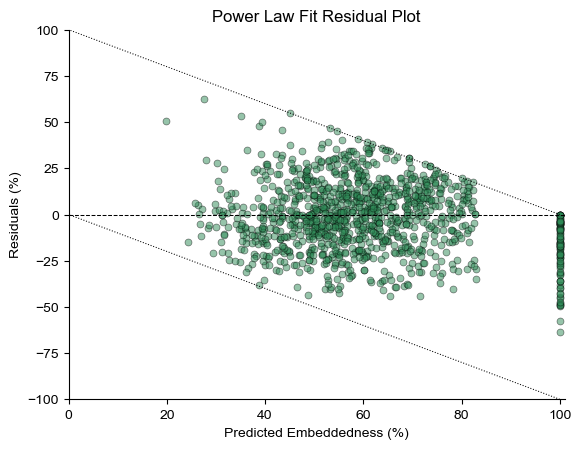

In [12]:
# Plot residuals
plt.scatter(predicted_Xembed_all, residuals, edgecolor = 'k', linewidth = 0.5, color = 'seagreen', alpha = 0.5, s = 25)
plt.xlabel('Predicted Embeddedness (%)')
plt.ylabel('Residuals (%)')
plt.title(f"Power Law Fit Residual Plot")
plt.axhline(y=0, color='k', linestyle='--', linewidth = 0.75)
plt.ylim([-100, 100])
plt.xlim([0, 101])

# Aesthetics
ax = plt.gca()
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot boundaries
plt.plot([100, 0], [0, 100],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75)
plt.plot([100, 0], [-100, 0],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75)

# Save figures
powerlaw_path = os.path.join(BASE_DIR, "virginia_streamstats", "eda", "figures", "va_power_residuals.png")
plt.savefig(powerlaw_path, dpi = 300)

plt.show()

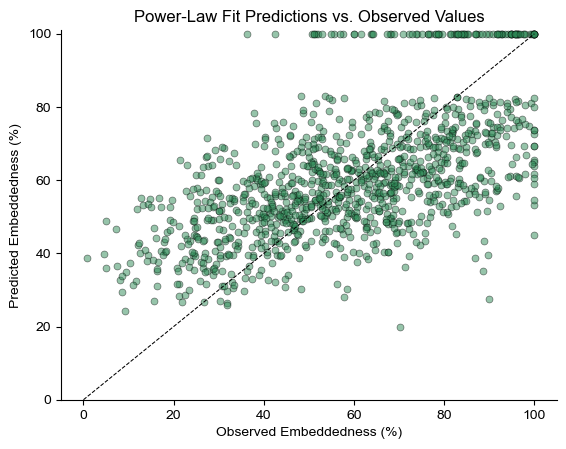

In [13]:
# Plot predictions vs true
plt.scatter(tmdl_emd['Xembed'],
            predicted_Xembed_all,
            color = 'seagreen',
            s = 25,
            edgecolors = 'black',
            linewidths = 0.5,
           alpha = 0.5)
plt.xlabel('Observed Embeddedness (%)', fontname = 'Arial')
plt.ylabel('Predicted Embeddedness (%)', fontname = 'Arial')
plt.title('Power-Law Fit Predictions vs. Observed Values', fontname = 'Arial')
plt.ylim([0, 101])

# Aesthetics
ax = plt.gca()
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Perfect fit line
plt.plot([0, 100], [0, 100],
         color = 'k',
         linestyle = '--',
         linewidth = 0.75)
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")

# Save figures
powerlaw_path = os.path.join(BASE_DIR, "virginia_streamstats", "eda", "figures", "va_power_predict_true.png")
plt.savefig(powerlaw_path, dpi = 300)

# Show plot
plt.show()

## Step 5. Create first visual EDAs

### Correlation (Pearson's R)

,ReachLength,Slope_x,RP100,BR_PCT,HP_PCT,RC_PCT,BL_PCT,CB_PCT,GC_PCT,GF_PCT,...,RDLEN,RDLEN120,STXRD_CNT,RDDENS,pctRoadLengthInRiparian,STXRD,LATITUDE,LONGITUDE,Slope [m/m],u* [m/s]
ReachLength,1.000000,-0.280171,0.476302,0.221207,-0.044699,-0.015188,0.196363,0.014564,-0.057700,-0.237832,...,0.753162,0.838152,0.857517,0.174820,0.087399,0.105165,0.041994,-0.088921,-0.280171,-0.214232
Slope_x,-0.280171,1.000000,-0.432404,0.129767,-0.196599,-0.011444,0.378619,0.290050,0.099190,0.147544,...,-0.265152,-0.249599,-0.279616,0.042626,0.312410,0.172459,-0.021429,-0.190864,1.000000,0.814142
RP100,0.476302,-0.432404,1.000000,-0.061880,0.188127,0.012730,-0.096670,-0.241509,-0.112760,-0.220726,...,0.368192,0.322866,0.368996,-0.124625,-0.210397,-0.059606,0.115752,0.248006,-0.432404,-0.397038
BR_PCT,0.221207,0.129767,-0.061880,1.000000,-0.207123,-0.042610,0.102545,0.026878,0.004243,-0.108198,...,0.065510,0.276938,0.209508,0.124061,0.214895,0.105116,-0.079052,-0.213500,0.129767,0.213024
HP_PCT,-0.044699,-0.196599,0.188127,-0.207123,1.000000,0.024957,-0.228036,-0.274549,-0.094674,0.057596,...,0.047453,-0.066327,-0.001791,-0.046059,-0.186097,0.028474,0.171213,0.309638,-0.196599,-0.216091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
STXRD,0.105165,0.172459,-0.059606,0.105116,0.028474,-0.019381,0.079672,0.046995,0.113334,0.085677,...,0.018931,0.130166,0.103957,0.648255,0.203259,1.000000,0.219558,-0.065502,0.172459,0.154981
LATITUDE,0.041994,-0.021429,0.115752,-0.079052,0.171213,0.008171,0.025487,0.161379,0.173187,0.036172,...,0.059040,0.011158,0.056578,0.106452,-0.052615,0.219558,1.000000,0.563864,-0.021429,0.007108
LONGITUDE,-0.088921,-0.190864,0.248006,-0.213500,0.309638,-0.013332,-0.278106,-0.326723,-0.124143,0.020374,...,0.210160,-0.035234,0.086997,-0.364245,-0.461441,-0.065502,0.563864,1.000000,-0.190864,-0.253400
Slope [m/m],-0.280171,1.000000,-0.432404,0.129767,-0.196599,-0.011444,0.378619,0.290050,0.099190,0.147544,...,-0.265152,-0.249599,-0.279616,0.042626,0.312410,0.172459,-0.021429,-0.190864,1.000000,0.814142


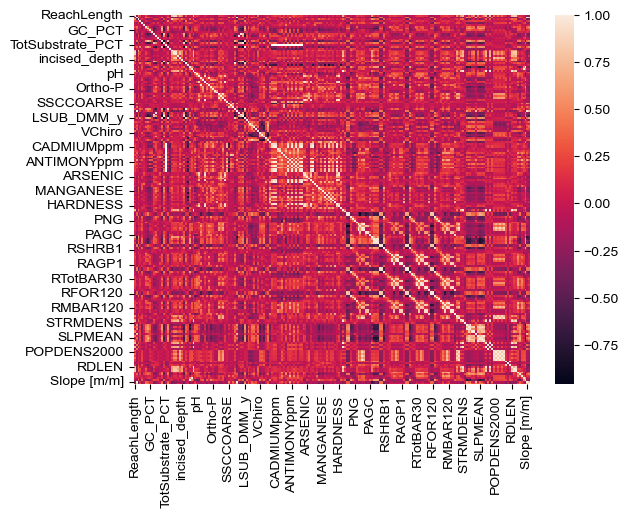

In [14]:
# Create correlation matrix and heatmap
num_df = tmdl_emd.select_dtypes(include='number')
corr = num_df.corr()

# Plot and print df
sns.heatmap(corr)
corr

### Reference Site Plotting

The Virginia DEQ also identifies monitoring sites as "Str," "Int,", and "Ref" using both biological (biota surveys) and physical (particle survey) attributes. They have already provided the spreadsheet of biological indicators, and we were provided with the criteria for habitat conditions, which are shown below:
1. <-1 = Stress
2. -1 to -0.5 = Intermediate
3. -0.5 to 0.5 = Ref
4. $>$0.5 = Int

These will be used for plotting the same scatter plot (bankfull shear velocity vs embeddedness) to explore correlations. 

#### Biological Endpoints

In [15]:
# Define path to reference site datasets
upland_path = os.path.join(BASE_DIR, "data", "raw", "virginia", "GenusMMI_Raw_Uplands_Data.xlsx")
coast_path = os.path.join(BASE_DIR, "data", "raw", "virginia", "GenusMMI_Raw_Coast_Data.xlsx")

# Import reference site datasets
upland_ref = pd.read_excel(upland_path)
coast_ref = pd.read_excel(coast_path)

# Select for only reference status (this is all we need for plotting right now)
upland_ref = upland_ref[['StationID', 'RefStress']]
coast_ref = coast_ref[['StationID', 'RefStress']]

In [16]:
# Select for only unique pairs
unique_upland_ref = upland_ref.drop_duplicates(subset=['StationID', 'RefStress'])
unique_coast_ref = coast_ref.drop_duplicates(subset = ['StationID', 'RefStress'])

In [17]:
# Join reference site information to the original dataset
join1 = tmdl_emd.merge(unique_upland_ref,
                           on = 'StationID',
                           how = "left")
join1[['RefStress']].describe()

,RefStress
count,604
unique,3
top,Ref
freq,221


In [18]:
# Join reference site information to the original dataset
join2 = tmdl_emd.merge(unique_coast_ref,
                                on = 'StationID',
                               how = "left")
join2[['RefStress']].describe()

,RefStress
count,30
unique,3
top,Ref
freq,12


In [19]:
# Concatenate two datasets into full testset dataset
vadeq_refs = pd.concat([join1, join2])
vadeq_refs[['RefStress']].describe()

,RefStress
count,634
unique,3
top,Ref
freq,233


In [20]:
# Check counts of each cat
vadeq_refs[['RefStress']].value_counts()

RefStress
Ref          233
Int          227
Str          174
Name: count, dtype: int64

In [26]:
# Change to categry dtype in case
vadeq_refs['RefStress'] = vadeq_refs['RefStress'].astype('category')

# Rename categores
vadeq_refs['RefStress'] = vadeq_refs['RefStress'].cat.rename_categories({'Str':'Stressed',
                                                            'Int':'Intermediate',
                                                            'Ref':'Reference'})

# Display df
vadeq_refs

,StationID,Date,ReachLength,Slope_x,RP100,BR_PCT,HP_PCT,RC_PCT,BL_PCT,CB_PCT,...,RDLEN120,STXRD_CNT,RDDENS,pctRoadLengthInRiparian,STXRD,LATITUDE,LONGITUDE,Slope [m/m],u* [m/s],RefStress
5,1ABRB002.15,2012-09-11,800,0.609000,39.257069,8.219178,0.000000,0.000000,30.136986,23.287671,...,NaN,NaN,NaN,NaN,NaN,39.046667,-77.432778,0.006090,0.241052,Stressed
8,1ACAX003.81,2012-08-23,480,0.164000,45.071218,12.621359,1.941748,0.000000,11.650485,19.417476,...,NaN,NaN,NaN,NaN,NaN,39.257700,-77.568500,0.001640,0.130436,Intermediate
12,1ACUB004.63,2009-11-18,440,0.135600,24.770415,0.952381,16.190476,0.000000,0.000000,20.000000,...,113241.6664,174.0,4.733257,16.884208,1.910074,38.841464,-77.463786,0.001356,0.113437,Stressed
14,1AGOO018.17,2012-08-21,400,0.087500,21.148451,0.000000,6.666667,0.000000,3.809524,1.904762,...,NaN,NaN,NaN,NaN,NaN,39.029900,-77.666000,0.000875,0.083422,Reference
17,1AHOR005.48,2010-11-09,280,0.235714,14.110694,0.000000,0.000000,0.000000,7.619048,22.857143,...,NaN,NaN,NaN,NaN,NaN,38.846467,-77.174789,0.002357,0.112768,Stressed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936,2-RHC000.58,2020-02-19,240,0.529000,20.243970,6.666667,4.761905,0.000000,12.380952,15.238095,...,NaN,NaN,NaN,NaN,NaN,37.217250,-77.444167,0.005290,0.217748,Intermediate
937,2-PCT002.46,2020-01-29,200,0.580000,9.251804,1.904762,0.952381,0.000000,3.809524,39.047619,...,NaN,NaN,NaN,NaN,NaN,37.380694,-77.422500,0.005800,0.185056,Intermediate
939,2-NTR000.23,2020-10-05,240,0.200000,15.119437,0.000000,5.714286,0.000000,3.809524,13.333333,...,NaN,NaN,NaN,NaN,NaN,37.617500,-77.457778,0.002000,0.123215,Intermediate
941,2CJOP000.34,2020-09-29,240,0.187500,18.087873,0.000000,1.904762,0.000000,3.809524,0.000000,...,NaN,NaN,NaN,NaN,NaN,37.595694,-77.476000,0.001875,0.110286,Stressed


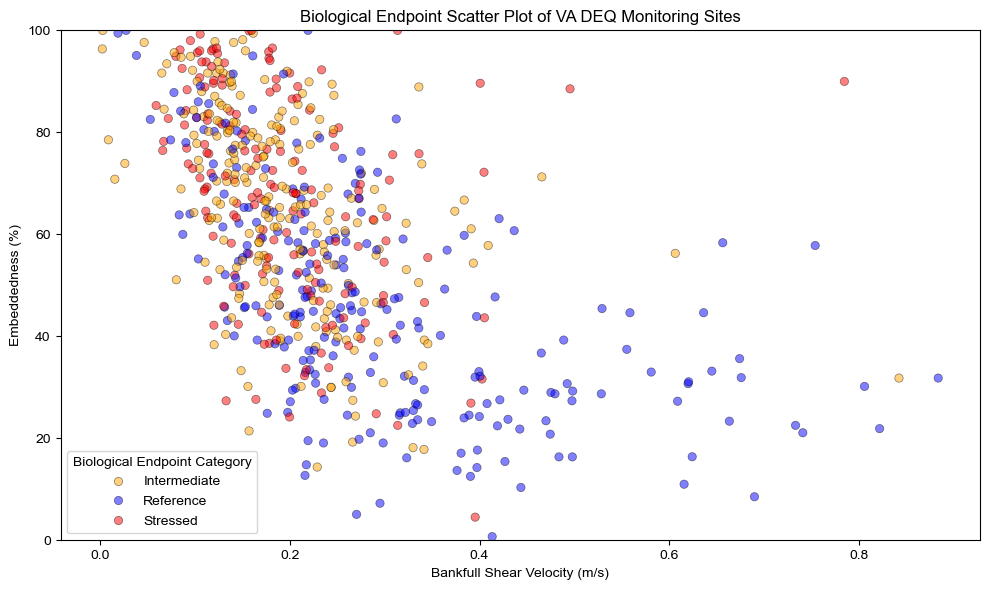

In [37]:
# Create same scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data = vadeq_refs, 
                x='u* [m/s]', 
                y='Xembed', 
                hue='RefStress', 
                palette={'Stressed': 'r', 'Intermediate': 'orange', 'Reference': 'b'},
               alpha = 0.5,
               edgecolor = 'k', linewidth = 0.5)

#  Aesthetics
plt.ylim(0, 100)
plt.xlabel('Bankfull Shear Velocity (m/s)', fontname = 'Arial')
plt.ylabel('Embeddedness (%)', fontname = 'Arial')
plt.title('Biological Endpoint Scatter Plot of VA DEQ Monitoring Sites', fontname = 'Arial')
plt.tight_layout()
plt.legend(title='Biological Endpoint Category')

# Save figure
ref_sctr_path = os.path.join(BASE_DIR, 'virginia_streamstats', 'eda', 'figures', 'vadeq_ref_scatter.png')
plt.savefig(ref_sctr_path, dpi = 300)

# Show plot
plt.show()

In [23]:
# Drop null values when in relation to reference stress
vadeq_refs.dropna(subset = 'RefStress', inplace = True)

#### Habitat Endpoint

In [35]:
# Apply criteria for habitat endpoints
conditions = [
    (vadeq_refs['LRBS2'] < -1),
    (vadeq_refs['LRBS2'] > -1) & (vadeq_refs['LRBS2'] < -0.5),
    (vadeq_refs['LRBS2'] > -0.5) & (vadeq_refs['LRBS2'] < 0.5),
    (vadeq_refs['LRBS2'] > 0.5)
]

# Define choices
choices = ['Stressed', 'Intermediate', 'Reference', 'Intermediate']

# Create a new column
vadeq_refs['Habitat Endpoint'] = np.select(conditions, choices, default = 'Unknown')

# Check that all values were captured
vadeq_refs['Habitat Endpoint'].isnull().sum()

0

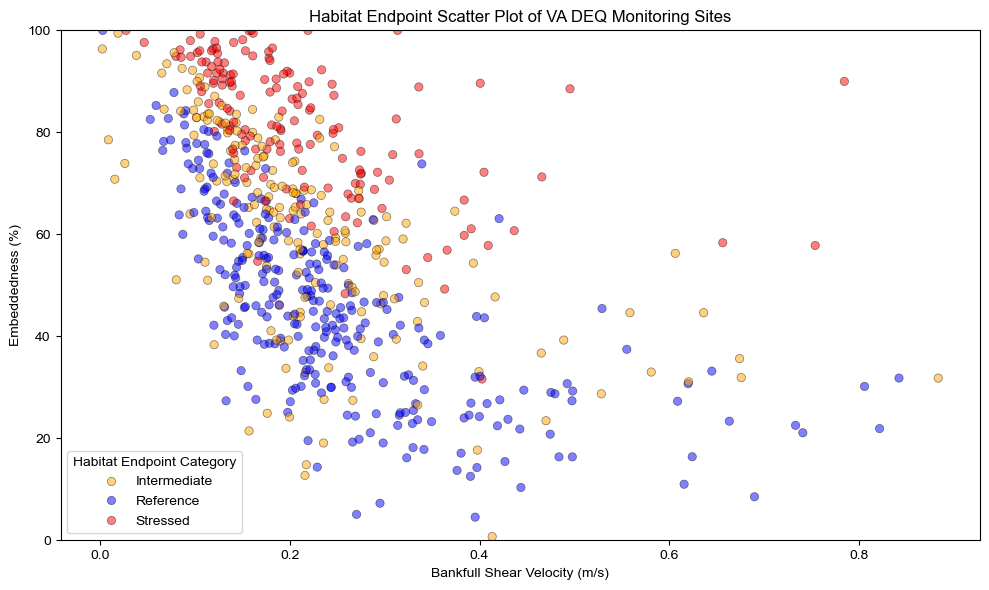

In [38]:
# Create scatterplot using habitat endpoints
plt.figure(figsize=(10, 6))
sns.scatterplot(data = vadeq_refs, 
                x='u* [m/s]', 
                y='Xembed', 
                hue='Habitat Endpoint', 
                palette={'Stressed': 'r', 'Intermediate': 'orange', 'Reference': 'b'},
               alpha = 0.5,
               edgecolor = 'k', linewidth = 0.5)

#  Aesthetics
plt.ylim(0, 100)
plt.xlabel('Bankfull Shear Velocity (m/s)', fontname = 'Arial')
plt.ylabel('Embeddedness (%)', fontname = 'Arial')
plt.title('Habitat Endpoint Scatter Plot of VA DEQ Monitoring Sites', fontname = 'Arial')
plt.tight_layout()
plt.legend(title='Habitat Endpoint Category')

# Save figure
hab_end_sctr_path = os.path.join(BASE_DIR, 'virginia_streamstats', 'eda', 'figures', 'vadeq_hab_end_scatter.png')
plt.savefig(hab_end_sctr_path, dpi = 300)

# Show plot
plt.show()

### Export Spreadsheet

In [39]:
# Push reference site information to processed folder for later use in analysis
ref_path = os.path.join(BASE_DIR, "data", "processed", "virginia", "vadeq_ref_sites_join.xlsx")
vadeq_refs.to_excel(ref_path)
print(f"Dataset saved to {ref_path}")

Dataset saved to C:\Users\reill\Documents\Virginia Tech\Czuba Research\Embeddedness\GitHub\Embeddedness_ML_XAI\data\processed\virginia\vadeq_ref_sites_join.xlsx
